# Grover's Search Algorithm
### Quantum Search with Quadratic Speedup — Qiskit Implementation

---

## What is Grover's Algorithm?

Suppose you have an **unsorted database of N items** and you want to find one specific item.  
Classically, the only option is to check items one by one — **O(N)** worst case, **O(N/2)** on average.

**Grover's algorithm (1996)** solves the same problem in **O(√N) quantum operations**.  
For N = 8, that's ~2 iterations instead of up to 8 checks. The speedup grows with N.

The key insight is **amplitude amplification**: instead of searching randomly, the algorithm  
repeatedly boosts the probability of the correct answer while suppressing all wrong ones.

| Metric            | Classical (linear scan)   | Grover's Algorithm  |
|-------------------|---------------------------|---------------------|
| Search time       | O(N)                      | O(√N)               |
| N = 8 (steps)     | up to 8, avg 4            | 2 iterations        |
| N = 1 000 000     | up to 1 000 000           | ~785 iterations     |
| Requires          | nothing special           | a quantum computer  |

> **Note:** The algorithm is provably optimal — no quantum algorithm can do better than O(√N)  
> for unstructured search *(BBBV theorem, 1994)*.

## How It Works — Big Picture

The algorithm operates on a superposition of all N basis states simultaneously.  
Each iteration applies two operations back-to-back:

```
|ψ⟩  →  Oracle  →  Diffuser  →  Oracle  →  Diffuser  →  ...  →  Measure
```

After the **optimal number of iterations** (≈ π/4 · √N), measuring the quantum state  
yields the target with high probability.

### Step 1 — Initialization
Apply a Hadamard gate to every qubit to create an **equal superposition**:
$$|000\rangle \xrightarrow{H^{\otimes n}} \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle$$
Every element in the database now has equal amplitude $1/\sqrt{N}$.

### Step 2 — The Oracle
The oracle marks the target state by flipping its **phase**:
$$\text{Oracle}|x\rangle = \begin{cases} -|x\rangle & \text{if } x = \text{target} \\ |x\rangle & \text{otherwise} \end{cases}$$
This phase flip is invisible on its own, but the diffuser turns it into a measurable amplitude difference.

### Step 3 — The Diffuser (Inversion About the Mean)
The diffuser reflects all amplitudes about their average:  
$$a_i \rightarrow 2\langle a \rangle - a_i$$
Because the oracle gave the target a **negative** amplitude, after reflection it ends up significantly larger than all others.

### Step 4 — Geometric Intuition
Each Oracle+Diffuser pair **rotates the state vector by 2θ** toward the target state,  
where $\sin(\theta) = 1/\sqrt{N}$. After $k = \text{round}(\pi/4 \cdot \sqrt{N})$ rotations, the state is nearly aligned with the target.

### Why Too Many Iterations Hurt
The rotation **overshoots** if you apply too many iterations. The probability oscillates  
sinusoidally — you'll see this clearly in the iteration experiment below.

---
## Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# ── Config ──────────────────────────────────────────────────────────────────
N_QUBITS = 3       # 2^3 = 8-element search space
TARGET   = 5       # the marked element we're searching for (|101⟩)
SHOTS    = 4096

N = 2 ** N_QUBITS
t_key = format(TARGET, f'0{N_QUBITS}b')   # Qiskit bitstring for target

print(f"Search space : {N} elements  (n={N_QUBITS} qubits)")
print(f"Target       : index {TARGET}  →  |{t_key}⟩")

Search space : 8 elements  (n=3 qubits)
Target       : index 5  →  |101⟩


---
## Classical Brute-Force Comparison

Before going quantum, let's see how a classical linear search performs.

In [2]:
def classical_search(database, target):
    """Linear scan — O(N) worst case."""
    for i, val in enumerate(database):
        if val == target:
            return i, i + 1   # (index, steps taken)
    return -1, len(database)


database = list(range(N))
idx, steps = classical_search(database, TARGET)

print(f"Classical brute-force: found at index {idx} after {steps} step(s)")
print(f"  Worst case : {N} steps")
print(f"  Average    : {N // 2} steps")

optimal_k = round(np.pi / 4 * np.sqrt(N))
print(f"\nOptimal Grover iterations : {optimal_k}  (≈ π/4 · √{N})")
print(f"Quantum speedup           : O(√N) vs O(N) classical")

Classical brute-force: found at index 5 after 6 step(s)
  Worst case : 8 steps
  Average    : 4 steps

Optimal Grover iterations : 2  (≈ π/4 · √8)
Quantum speedup           : O(√N) vs O(N) classical


---
## Building the Phase Oracle

The oracle marks the target state `|101⟩` (index 5) by applying a −1 phase to it.

**Circuit strategy:**
1. Flip every qubit where the target bit is `0`, mapping the target to `|111...1⟩`.
2. Apply a **multi-controlled Z** (MCZ) — this gives −1 phase only to `|111...1⟩`.
3. Undo the bit flips to restore the original basis.

The MCZ itself is built as `H · MCX · H` on the last qubit, which converts the  
controlled-X into a controlled-Z via the Hadamard identity: **HXH = Z**.

Phase Oracle circuit:


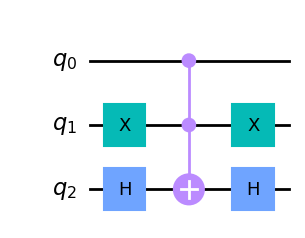

In [3]:
def phase_oracle(n, target):
    """
    Phase oracle for a single marked state.
    Net effect: |target⟩ → -|target⟩,  all other states unchanged.
    """
    qc = QuantumCircuit(n, name='Oracle')

    # bits[i] is the expected bit for qubit i (LSB first, matches Qiskit ordering)
    bits = format(target, f'0{n}b')[::-1]

    # step 1: flip qubits where target bit is 0 → target maps to |111...1⟩
    for i, b in enumerate(bits):
        if b == '0':
            qc.x(i)

    # step 2: MCZ via H + MCX + H on the last qubit
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # step 3: undo the bit flips
    for i, b in enumerate(bits):
        if b == '0':
            qc.x(i)

    return qc


# Draw the oracle circuit
oracle = phase_oracle(N_QUBITS, TARGET)
print("Phase Oracle circuit:")
oracle.draw(output='mpl', style='clifford')

---
## Building the Diffuser

The diffuser (a.k.a. **inversion about the mean**) amplifies the marked state.  
Geometrically: it reflects the state vector about the uniform superposition `|s⟩`.

**Circuit:** `H → X → MCZ → X → H`
- `H` maps `|s⟩` to `|0...0⟩`
- `X` maps `|0...0⟩` to `|1...1⟩`
- MCZ applies −1 phase to `|1...1⟩`
- `X`, `H` undo the mapping

Combined with the oracle's phase flip, this boosts the target's amplitude each iteration.

Diffuser circuit:


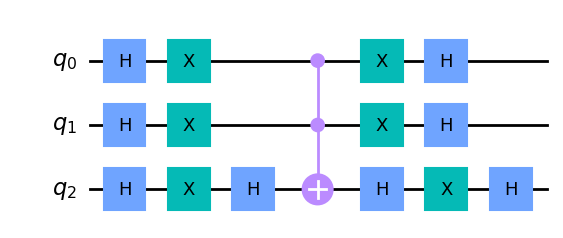

In [4]:
def diffuser(n):
    """
    Grover diffusion operator — 'inversion about the mean'.
    Circuit: H X MCZ X H
    """
    qc = QuantumCircuit(n, name='Diffuser')
    qc.h(range(n))
    qc.x(range(n))
    # MCZ on all qubits (H + MCX + H trick)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    return qc


# Draw the diffuser circuit
diff = diffuser(N_QUBITS)
print("Diffuser circuit:")
diff.draw(output='mpl', style='clifford')

---
## Full Grover Circuit

Putting it all together:
1. Hadamard on all qubits → uniform superposition
2. Repeat `k` times: Oracle → Diffuser
3. Measure all qubits

Full Grover circuit  (2 iteration(s), target = |101⟩):


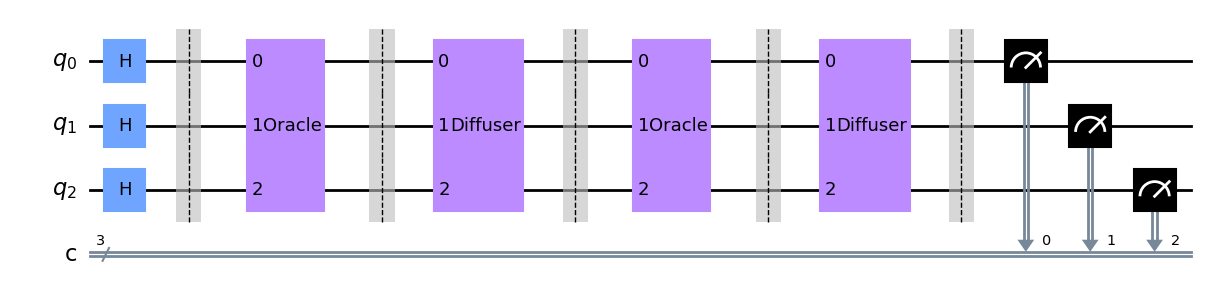

In [5]:
def grover_circuit(n, target, iterations):
    qc = QuantumCircuit(n, n)

    # uniform superposition over all 2^n basis states
    qc.h(range(n))
    qc.barrier()

    oracle_gate   = phase_oracle(n, target).to_gate()
    diffuser_gate = diffuser(n).to_gate()

    for _ in range(iterations):
        qc.append(oracle_gate, range(n))
        qc.barrier()
        qc.append(diffuser_gate, range(n))
        qc.barrier()

    qc.measure(range(n), range(n))
    return qc


# Build the circuit with the optimal number of iterations
qc = grover_circuit(N_QUBITS, TARGET, optimal_k)

print(f"Full Grover circuit  ({optimal_k} iteration(s), target = |{t_key}⟩):")
qc.draw(output='mpl', fold=40, style='clifford')

---
## Simulation

We run the circuit on **Qiskit's AerSimulator** (a classical quantum circuit emulator)  
using 4096 shots to get a statistically meaningful probability distribution.

In [6]:
def run_circuit(qc, shots=SHOTS):
    sim      = AerSimulator()
    compiled = transpile(qc, sim)
    result   = sim.run(compiled, shots=shots).result()
    return result.get_counts()


counts = run_circuit(qc)

print("Top measurement outcomes:")
for state, cnt in sorted(counts.items(), key=lambda x: -x[1])[:6]:
    bar    = '█' * int(cnt / SHOTS * 40)
    marker = '  ← target' if state == t_key else ''
    print(f"  |{state}⟩  {cnt:4d}/{SHOTS}  {cnt/SHOTS*100:5.1f}%  {bar}{marker}")

Top measurement outcomes:
  |101⟩  3872/4096   94.5%  █████████████████████████████████████  ← target
  |110⟩    41/4096    1.0%  
  |010⟩    33/4096    0.8%  
  |111⟩    32/4096    0.8%  
  |001⟩    32/4096    0.8%  
  |011⟩    31/4096    0.8%  


---
## Measurement Histogram

The histogram shows the probability distribution over all 8 basis states.  
With the optimal number of iterations, the target state `|101⟩` should dominate.

In [7]:
fig = plot_histogram(
    counts,
    title=f"Grover's Algorithm — Marked state: |{t_key}⟩  ({optimal_k} iteration(s))",
    figsize=(9, 4),
    color='steelblue',
)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

---
## Iteration Experiment

What happens if we apply too few or too many iterations?  
We run Grover's for k = 1..6 and record P(target) each time.

The probability of measuring the target **oscillates sinusoidally**:  
it rises to a peak at `k ≈ π/4 · √N` then falls back — this is the geometry at work.

In [8]:
def iteration_experiment(n, target, max_iter=6):
    """Run Grover's for k = 1..max_iter and record P(target) each time."""
    target_key = format(target, f'0{n}b')
    probs = []

    for k in range(1, max_iter + 1):
        qc_k   = grover_circuit(n, target, k)
        counts = run_circuit(qc_k)
        prob   = counts.get(target_key, 0) / SHOTS
        probs.append(prob)
        print(f"  k={k}  P(|{target_key}⟩) = {prob:.3f}")

    return probs


print("Iteration experiment — P(target) vs. number of iterations:")
probs = iteration_experiment(N_QUBITS, TARGET, max_iter=6)

Iteration experiment — P(target) vs. number of iterations:
  k=1  P(|101⟩) = 0.785
  k=2  P(|101⟩) = 0.942
  k=3  P(|101⟩) = 0.333
  k=4  P(|101⟩) = 0.014
  k=5  P(|101⟩) = 0.553
  k=6  P(|101⟩) = 1.000


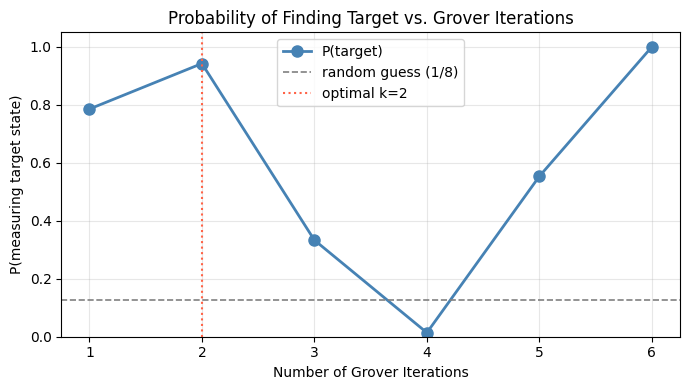

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 7), probs, 'o-', color='steelblue', linewidth=2, markersize=8, label='P(target)')
ax.axhline(1 / N, color='gray', linestyle='--', linewidth=1.2, label=f'random guess (1/{N})')
ax.axvline(optimal_k, color='tomato', linestyle=':', linewidth=1.5, label=f'optimal k={optimal_k}')
ax.set_xlabel('Number of Grover Iterations')
ax.set_ylabel('P(measuring target state)')
ax.set_title('Probability of Finding Target vs. Grover Iterations')
ax.set_ylim(0, 1.05)
ax.set_xticks(range(1, 7))
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

---
## Scaling: Qubits vs. Required Iterations

Let's visualize how the optimal iteration count scales as the search space grows.  
Grover's grows as **O(√N)** while classical search grows as **O(N)** — the gap widens quickly.

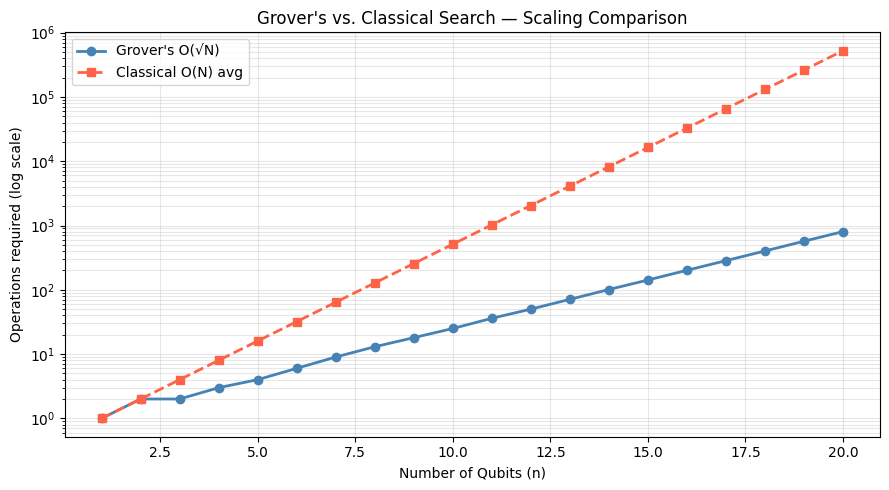


  Qubits           N    Grover k   Classical avg
------------------------------------------------
       1           2           1               1
       2           4           2               2
       3           8           2               4
       4          16           3               8
       5          32           4              16
       6          64           6              32
       7         128           9              64
       8         256          13             128
       9         512          18             256
      10        1024          25             512
      11        2048          36            1024
      12        4096          50            2048
      13        8192          71            4096
      14       16384         101            8192
      15       32768         142           16384
      16       65536         201           32768
      17      131072         284           65536
      18      262144         402          131072
      19      52428

In [10]:
qubit_range = range(1, 21)
N_values    = [2**n for n in qubit_range]
grover_iters = [round(np.pi / 4 * np.sqrt(N)) for N in N_values]
classical_avg = [N // 2 for N in N_values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(qubit_range), grover_iters,  'o-', color='steelblue', linewidth=2, label="Grover's O(√N)")
ax.plot(list(qubit_range), classical_avg, 's--', color='tomato',    linewidth=2, label='Classical O(N) avg')
ax.set_yscale('log')
ax.set_xlabel('Number of Qubits (n)')
ax.set_ylabel('Operations required (log scale)')
ax.set_title("Grover's vs. Classical Search — Scaling Comparison")
ax.legend()
ax.grid(alpha=0.3, which='both')
fig.tight_layout()
plt.show()

print(f"\n{'Qubits':>8}  {'N':>10}  {'Grover k':>10}  {'Classical avg':>14}")
print('-' * 48)
for n, Nv, gk, cl in zip(qubit_range, N_values, grover_iters, classical_avg):
    print(f"{n:>8}  {Nv:>10}  {gk:>10}  {cl:>14}")

---
## Summary

| Component | Role |
|-----------|------|
| **Hadamard (H⊗n)** | Creates equal superposition over all N states |
| **Phase Oracle** | Marks the target by flipping its amplitude sign |
| **Diffuser** | Amplifies the target via inversion about the mean |
| **Measurement** | Collapses to target state with high probability |

**Key takeaways:**
- Grover's achieves a **quadratic speedup** over the best possible classical algorithm.
- The speedup is provably optimal (BBBV theorem) — no quantum algorithm can do better.
- Applying **too many or too few** iterations degrades performance (sinusoidal oscillation).
- The algorithm generalises to **multiple marked states** and is a building block for many other quantum algorithms.

---

## References

- L. K. Grover, *"A fast quantum mechanical algorithm for database search"*, STOC 1996.
- Bennett, Bernstein, Brassard, Vazirani, *"Strengths and Weaknesses of Quantum Computing"*, 1997 (BBBV theorem).
- Nielsen & Chuang, *Quantum Computation and Quantum Information*, Chapter 6.
- Qiskit documentation: https://docs.quantum.ibm.com